# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Diego Fernando Marin, 2024

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [1]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/proyecto_oro/"
except ImportError:
    BASE_PATH = "./_ci_cache/"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

CLEAN_PATH = BASE_PATH + "data/clean/"
df = pd.read_csv(CLEAN_PATH + "oro_cop_limpio.csv", index_col='DATE', parse_dates=True)

# Retornos
df['retorno_oro_cop']  = df['oro_cop'].pct_change(fill_method=None)
df['retorno_usd_cop']  = df['usd_cop_Close'].pct_change(fill_method=None)
df['retorno_dxy']      = df['dxy_Close'].pct_change(fill_method=None)
df['retorno_vix']      = df['vix_Close'].pct_change(fill_method=None)
df['retorno_wti']      = df['wti_crudo_Close'].pct_change(fill_method=None)
df['retorno_bono_10y'] = df['bono_10y_Close'].pct_change(fill_method=None)

# Lags seleccionados de usd_cop (validados en EDA)
for lag in [5, 8, 10, 16]:
    df[f'usd_cop_lag_{lag}'] = df['retorno_usd_cop'].shift(lag)

# Variables macro con 1 día de rezago (sin fuga de información)
df['retorno_dxy_lag1']      = df['retorno_dxy'].shift(1)
df['retorno_vix_lag1']      = df['retorno_vix'].shift(1)
df['retorno_wti_lag1']      = df['retorno_wti'].shift(1)
df['retorno_bono_10y_lag1'] = df['retorno_bono_10y'].shift(1)

# Dummies de día de semana
dummies_dia = pd.get_dummies(df.index.dayofweek, prefix='dia', drop_first=True)
dummies_dia.index = df.index
df = pd.concat([df, dummies_dia], axis=1)

print(f"Filas: {len(df)} | Columnas: {len(df.columns)}")


Filas: 1426 | Columnas: 25


In [2]:
FEATURES = [
    'usd_cop_lag_5', 'usd_cop_lag_8', 'usd_cop_lag_10', 'usd_cop_lag_16',
    'dia_1', 'dia_2', 'dia_3', 'dia_4',
    'retorno_dxy_lag1', 'retorno_vix_lag1', 'retorno_wti_lag1', 'retorno_bono_10y_lag1',
]
TARGET = 'retorno_oro_cop'

df_modelo = df.dropna(subset=FEATURES + [TARGET])
X = df_modelo[FEATURES]
y = df_modelo[TARGET]

print(f"Filas para entrenar: {len(df_modelo)}")

Filas para entrenar: 1409


In [3]:
tscv = TimeSeriesSplit(n_splits=6)
resultados = []

for i, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    modelo = LinearRegression()
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)

    rmse_modelo = np.sqrt(mean_squared_error(y_te, pred))
    rmse_ref = np.sqrt(mean_squared_error(y_te, np.zeros(len(y_te))))
    mejora_pct = (rmse_ref - rmse_modelo) / rmse_ref * 100

    resultados.append({
        'ventana': i, 'rmse_modelo': rmse_modelo,
        'rmse_referencia': rmse_ref, 'mejora_%': mejora_pct,
        'gano': rmse_modelo < rmse_ref
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)
print(f"\nVentanas ganadas: {df_resultados['gano'].sum()} de {len(df_resultados)}")
print(f"Mejora promedio: {df_resultados['mejora_%'].mean():.2f}%")

   ventana  rmse_modelo  rmse_referencia  mejora_%   gano
0        1     0.013208         0.013173 -0.260920  False
1        2     0.015307         0.016016  4.424374   True
2        3     0.011525         0.012372  6.852358   True
3        4     0.011953         0.013134  8.989940   True
4        5     0.015374         0.015881  3.192509   True
5        6     0.020923         0.021269  1.626257   True

Ventanas ganadas: 5 de 6
Mejora promedio: 4.14%


### Visualización: cómo se dividen los datos en entrenamiento y prueba

Antes de comparar modelos, es útil ver *físicamente* cómo `TimeSeriesSplit` reparte las filas. En cada una de las 6 ventanas, el entrenamiento (azul) crece porque incluye todo lo anterior, y la prueba (naranja) es siempre un bloque de días que el modelo todavía no ha visto y que viene *después* del entrenamiento — nunca se mezclan datos del futuro con el pasado.

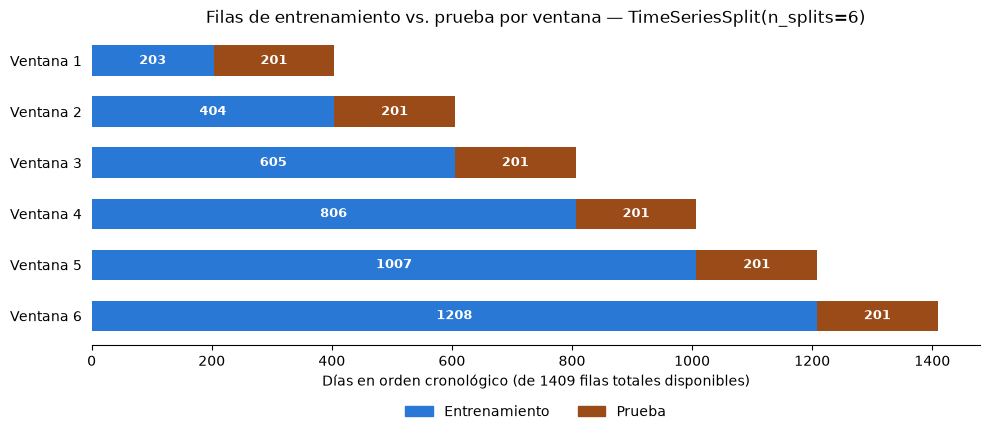

In [4]:
from matplotlib.patches import Patch

COLOR_TRAIN_VIZ = '#2a78d6'  # azul, mismo color usado para el modelo en el resto del cuaderno
COLOR_TEST_VIZ  = '#9A4B18'  # terracota, el mismo acento usado en el trabajo de grado y la presentación

ventanas_viz = list(TimeSeriesSplit(n_splits=6).split(X))

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (train_idx, test_idx) in enumerate(ventanas_viz, 1):
    n_train, n_test = len(train_idx), len(test_idx)
    ax.barh(i, n_train, color=COLOR_TRAIN_VIZ, height=0.6)
    ax.barh(i, n_test, left=n_train, color=COLOR_TEST_VIZ, height=0.6)
    ax.text(n_train / 2, i, f'{n_train}', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')
    ax.text(n_train + n_test / 2, i, f'{n_test}', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')

ax.set_yticks(range(1, len(ventanas_viz) + 1))
ax.set_yticklabels([f'Ventana {i}' for i in range(1, len(ventanas_viz) + 1)])
ax.invert_yaxis()
ax.set_xlabel(f'Días en orden cronológico (de {len(X)} filas totales disponibles)')
ax.set_title('Filas de entrenamiento vs. prueba por ventana — TimeSeriesSplit(n_splits=6)')
ax.legend(handles=[Patch(color=COLOR_TRAIN_VIZ, label='Entrenamiento'),
                    Patch(color=COLOR_TEST_VIZ, label='Prueba')],
          loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()


### Por fechas: ¿por qué 6 ventanas y no un solo año de prueba?

La gráfica anterior mostraba *cuántas* filas entran en cada ventana. Esta muestra *de qué fecha a qué fecha*, y además la compara contra la alternativa más simple: entrenar con todo hasta hace un año y probar solo con el último año (fila superior). Con un solo split se obtiene **una sola medición** del desempeño del modelo; con las 6 ventanas walk-forward se obtienen 6 mediciones en 6 periodos históricos distintos, lo que demuestra si el modelo funciona de forma consistente y no solo en un año en particular. En todos los casos el entrenamiento arranca en la misma fecha (el primer día disponible tras aplicar los rezagos) y la prueba es siempre el bloque de días inmediatamente posterior — nunca se eligen fechas al azar.

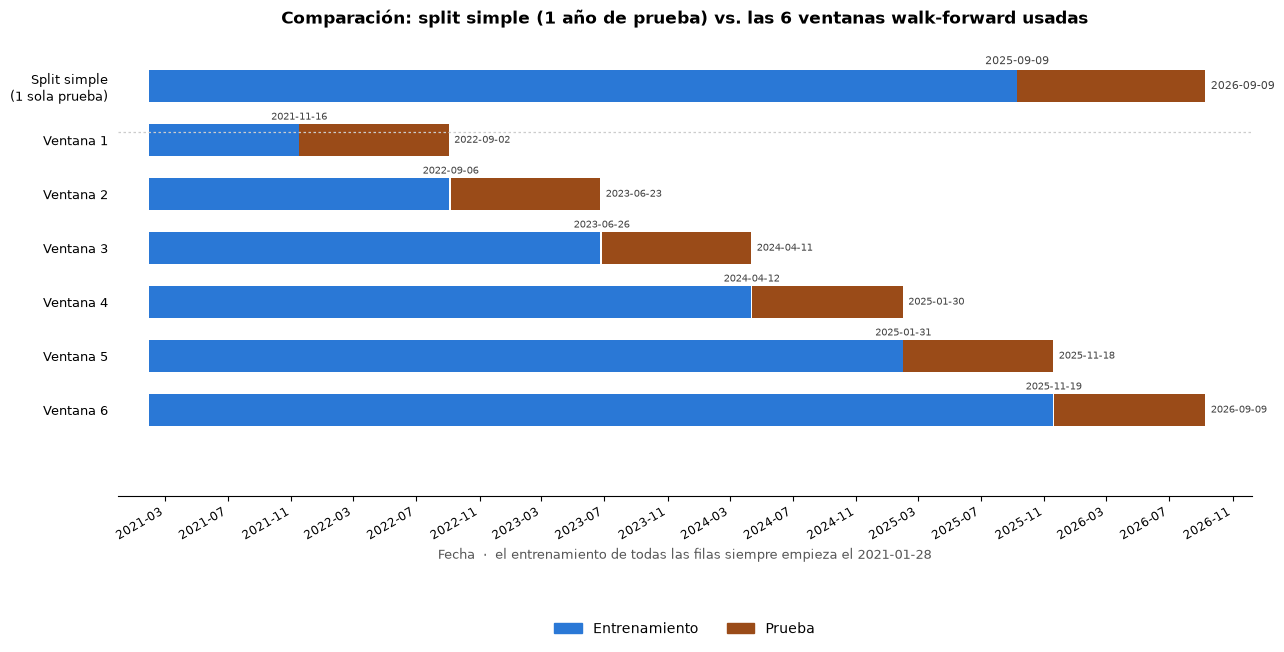

In [5]:
import matplotlib.dates as mdates

def _num(d):
    return mdates.date2num(d)

fig, ax = plt.subplots(figsize=(13, 6.8))
filas_labels = []

# --- Fila 0: split simple, ultimo ano como prueba (solo para comparar) ---
cutoff = X.index.max() - pd.Timedelta(days=365)
train_mask = X.index < cutoff
test_mask = ~train_mask
tr_dates = X.index[train_mask]
te_dates = X.index[test_mask]

fila0 = 0
ax.barh(fila0, _num(tr_dates[-1]) - _num(tr_dates[0]), left=_num(tr_dates[0]), color=COLOR_TRAIN_VIZ, height=0.6)
ax.barh(fila0, _num(te_dates[-1]) - _num(te_dates[0]), left=_num(te_dates[0]), color=COLOR_TEST_VIZ, height=0.6)
filas_labels.append((fila0, 'Split simple\n(1 sola prueba)'))
ax.annotate(te_dates[0].strftime('%Y-%m-%d'), (_num(te_dates[0]), fila0), xytext=(0, 14),
            textcoords='offset points', ha='center', va='bottom', fontsize=7.8, color='#444')
ax.annotate(te_dates[-1].strftime('%Y-%m-%d'), (_num(te_dates[-1]), fila0), xytext=(4, 0),
            textcoords='offset points', ha='left', va='center', fontsize=7.8, color='#444')

ax.axhline(0.85, color='#cccccc', linewidth=0.9, linestyle=(0, (2, 2)))

# --- Filas 1-6: las 6 ventanas walk-forward reales ---
for i, (tr_idx, te_idx) in enumerate(TimeSeriesSplit(n_splits=6).split(X), 1):
    fila = i
    d_tr0, d_tr1 = X.index[tr_idx[0]], X.index[tr_idx[-1]]
    d_te0, d_te1 = X.index[te_idx[0]], X.index[te_idx[-1]]
    ax.barh(fila, _num(d_tr1) - _num(d_tr0), left=_num(d_tr0), color=COLOR_TRAIN_VIZ, height=0.6)
    ax.barh(fila, _num(d_te1) - _num(d_te0), left=_num(d_te0), color=COLOR_TEST_VIZ, height=0.6)
    filas_labels.append((fila, f'Ventana {i}'))
    ax.annotate(d_te0.strftime('%Y-%m-%d'), (_num(d_te0), fila), xytext=(0, 13),
                textcoords='offset points', ha='center', va='bottom', fontsize=7.3, color='#444')
    ax.annotate(d_te1.strftime('%Y-%m-%d'), (_num(d_te1), fila), xytext=(4, 0),
                textcoords='offset points', ha='left', va='center', fontsize=7.3, color='#444')

ax.set_yticks([fila for fila, _ in filas_labels])
ax.set_yticklabels([lab for _, lab in filas_labels], fontsize=9.5)
ax.invert_yaxis()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8.5)

ax.set_title('Comparación: split simple (1 año de prueba) vs. las 6 ventanas walk-forward usadas',
              fontsize=12.5, fontweight='bold', pad=14)
ax.set_xlabel(f'Fecha  ·  el entrenamiento de todas las filas siempre empieza el {tr_dates[0].strftime("%Y-%m-%d")}',
              fontsize=9.5, color='#555')

ax.legend(handles=[Patch(color=COLOR_TRAIN_VIZ, label='Entrenamiento'), Patch(color=COLOR_TEST_VIZ, label='Prueba')],
          loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False, fontsize=10)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.set_ylim(7.6, -0.8)
ax.set_xlim(_num(X.index[0]) - 60, _num(X.index[-1]) + 90)

plt.tight_layout()
plt.show()

# Nota: se usan 'fila'/'fila0' (no 'y') a proposito, para no pisar la
# variable global 'y' (el retorno objetivo) que usan las celdas siguientes.


In [6]:
!pip install lightgbm xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                    BayesianRidge, HuberRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                                AdaBoostRegressor, ExtraTreesRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [7]:
modelos = {
    "Linear Regression":    LinearRegression(),
    "Ridge":                Ridge(alpha=1.0),
    "Lasso":                Lasso(alpha=0.001),
    "ElasticNet":           ElasticNet(alpha=0.001),
    "Bayesian Ridge":       BayesianRidge(),
    "Huber Regressor":      HuberRegressor(),
    "Decision Tree":        DecisionTreeRegressor(max_depth=4, random_state=42),
    "Random Forest":        RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42),
    "Extra Trees":          ExtraTreesRegressor(n_estimators=200, max_depth=4, random_state=42),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    "AdaBoost":             AdaBoostRegressor(n_estimators=100, random_state=42),
    "LightGBM":             LGBMRegressor(n_estimators=100, max_depth=4, verbose=-1, random_state=42),
    "XGBoost":              XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0),
    "SVR (RBF)":            SVR(kernel='rbf', C=1.0),
    "K-Nearest Neighbors":  KNeighborsRegressor(n_neighbors=10),
}

print(f"Total de modelos a probar: {len(modelos)}")

Total de modelos a probar: 15


In [8]:
tscv = TimeSeriesSplit(n_splits=6)
resultados_todos = []

for nombre, modelo in modelos.items():
    rmses_modelo = []
    rmses_ref = []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        modelo.fit(X_tr, y_tr)
        pred = modelo.predict(X_te)

        rmses_modelo.append(np.sqrt(mean_squared_error(y_te, pred)))
        rmses_ref.append(np.sqrt(mean_squared_error(y_te, np.zeros(len(y_te)))))

    rmse_prom = np.mean(rmses_modelo)
    rmse_ref_prom = np.mean(rmses_ref)
    mejora_pct = (rmse_ref_prom - rmse_prom) / rmse_ref_prom * 100
    ventanas_ganadas = sum(m < r for m, r in zip(rmses_modelo, rmses_ref))

    resultados_todos.append({
        "modelo": nombre,
        "rmse_promedio": rmse_prom,
        "mejora_%": mejora_pct,
        "ventanas_ganadas": ventanas_ganadas,
    })
    print(f"✓ {nombre}: RMSE={rmse_prom:.5f} | mejora={mejora_pct:.2f}% | ganó {ventanas_ganadas}/6")

df_ranking = pd.DataFrame(resultados_todos).sort_values("mejora_%", ascending=False).reset_index(drop=True)

✓ Linear Regression: RMSE=0.01471 | mejora=3.87% | ganó 5/6
✓ Ridge: RMSE=0.01500 | mejora=1.99% | ganó 5/6
✓ Lasso: RMSE=0.01529 | mejora=0.09% | ganó 5/6
✓ ElasticNet: RMSE=0.01528 | mejora=0.18% | ganó 6/6
✓ Bayesian Ridge: RMSE=0.01495 | mejora=2.34% | ganó 6/6


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/opt/hostedt

✓ Huber Regressor: RMSE=0.01482 | mejora=3.17% | ganó 5/6
✓ Decision Tree: RMSE=0.01591 | mejora=-3.93% | ganó 1/6


✓ Random Forest: RMSE=0.01506 | mejora=1.60% | ganó 5/6


✓ Extra Trees: RMSE=0.01499 | mejora=2.05% | ganó 5/6


✓ Gradient Boosting: RMSE=0.01541 | mejora=-0.65% | ganó 5/6


✓ AdaBoost: RMSE=0.01512 | mejora=1.21% | ganó 5/6
✓ LightGBM: RMSE=0.01539 | mejora=-0.52% | ganó 4/6


✓ XGBoost: RMSE=0.01588 | mejora=-3.72% | ganó 3/6
✓ SVR (RBF): RMSE=0.01569 | mejora=-2.48% | ganó 2/6
✓ K-Nearest Neighbors: RMSE=0.01530 | mejora=0.07% | ganó 5/6


In [9]:
print(df_ranking.to_string())

                 modelo  rmse_promedio  mejora_%  ventanas_ganadas
0     Linear Regression       0.014715  3.871328                 5
1       Huber Regressor       0.014823  3.166136                 5
2        Bayesian Ridge       0.014950  2.336263                 6
3           Extra Trees       0.014994  2.048421                 5
4                 Ridge       0.015003  1.991056                 5
5         Random Forest       0.015063  1.599238                 5
6              AdaBoost       0.015122  1.213228                 5
7            ElasticNet       0.015279  0.183638                 6
8                 Lasso       0.015294  0.087033                 5
9   K-Nearest Neighbors       0.015297  0.067199                 5
10             LightGBM       0.015388 -0.523727                 4
11    Gradient Boosting       0.015406 -0.645043                 5
12            SVR (RBF)       0.015687 -2.477632                 2
13              XGBoost       0.015877 -3.721575              

In [10]:
from matplotlib.ticker import FuncFormatter

# Misma paleta de color usada en 03_EDA.ipynb, para que las graficas de
# ambos cuadernos se lean como un solo sistema visual.
COLOR_PRINCIPAL = '#2a78d6'   # azul - modelo / valores positivos
COLOR_MUTED     = '#c3c2b7'   # gris - referencia / contexto
COLOR_CRITICO   = '#d03b3b'   # rojo - valores negativos / peor que la referencia
COLOR_REAL      = '#0b0b0b'   # tinta oscura - el valor real observado
fmt_cop = FuncFormatter(lambda x, _: f"{x:,.0f}")


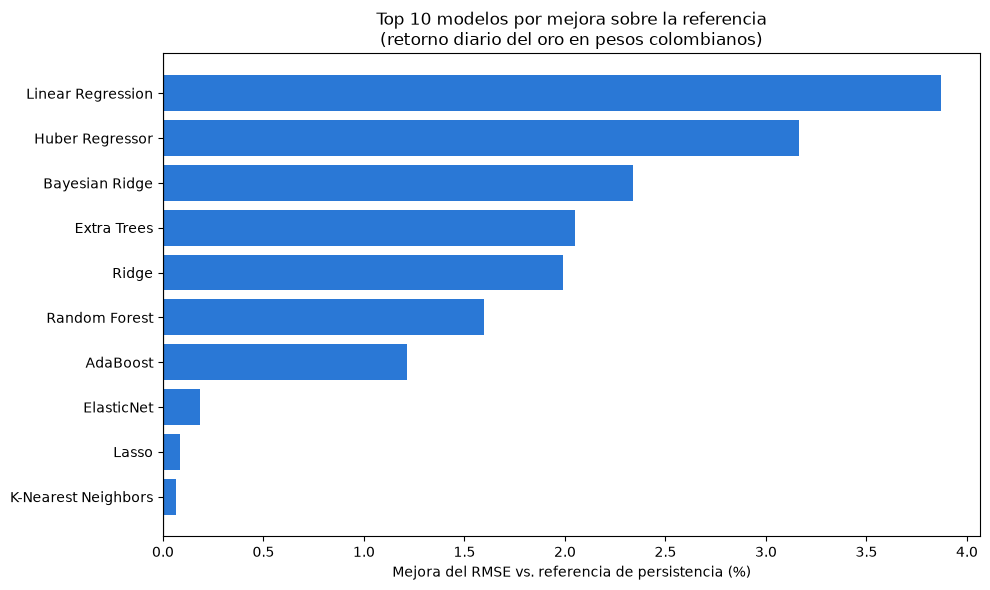

In [11]:
top10 = df_ranking.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colores = [COLOR_PRINCIPAL if v > 0 else COLOR_CRITICO for v in top10['mejora_%']]
ax.barh(top10['modelo'][::-1], top10['mejora_%'][::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mejora del RMSE vs. referencia de persistencia (%)')
ax.set_title('Top 10 modelos por mejora sobre la referencia\n(retorno diario del oro en pesos colombianos)')
plt.tight_layout()
plt.show()


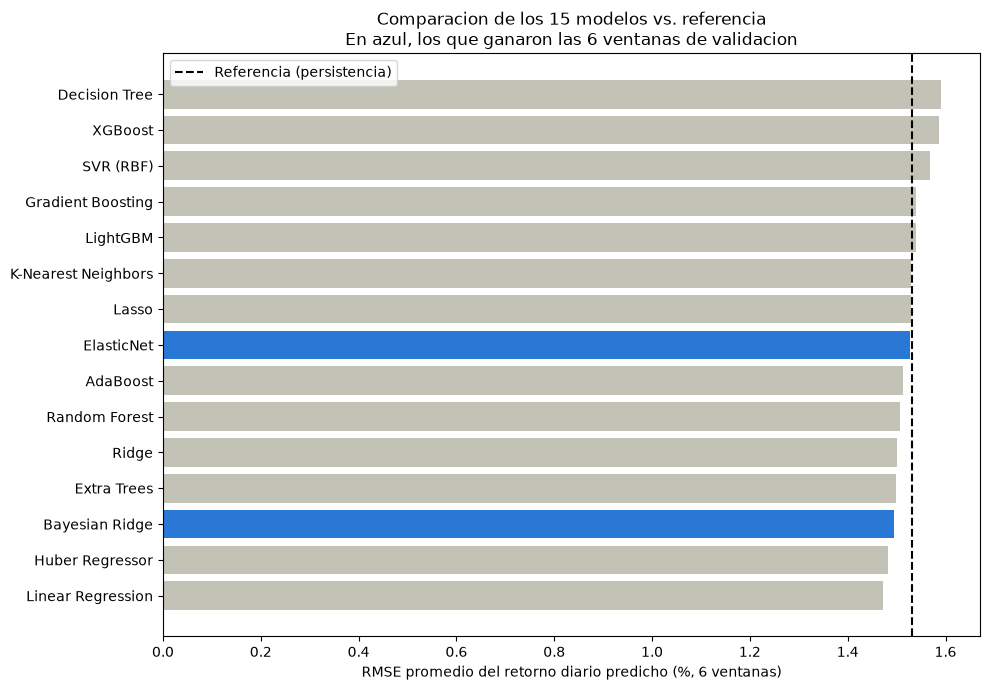

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))
df_plot = df_ranking.sort_values("rmse_promedio")
colores2 = [COLOR_PRINCIPAL if g == 6 else COLOR_MUTED for g in df_plot['ventanas_ganadas']]
ax.barh(df_plot['modelo'], df_plot['rmse_promedio'] * 100, color=colores2)
ax.axvline(rmse_ref_prom * 100, color='black', linestyle='--', label='Referencia (persistencia)')
ax.set_xlabel('RMSE promedio del retorno diario predicho (%, 6 ventanas)')
ax.set_title('Comparacion de los 15 modelos vs. referencia\nEn azul, los que ganaron las 6 ventanas de validacion')
ax.legend()
plt.tight_layout()
plt.show()


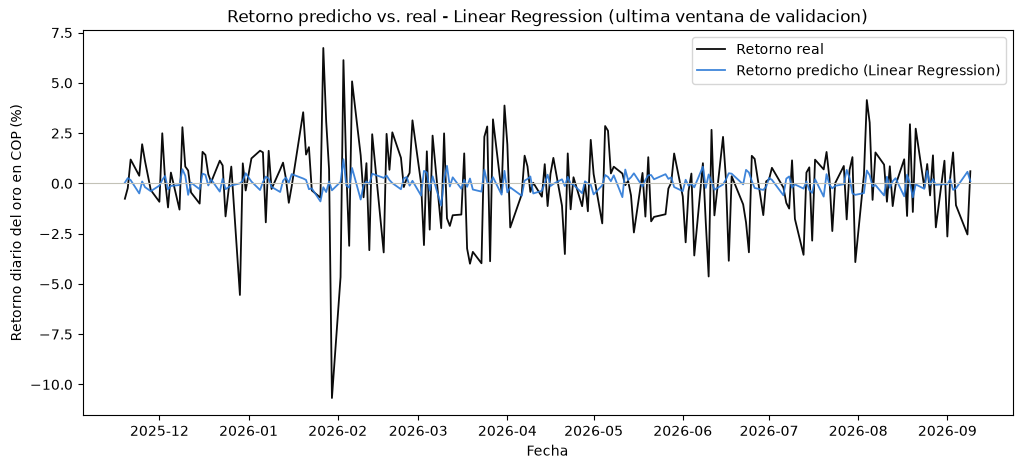

In [13]:
mejor_nombre = df_ranking.iloc[0]['modelo']
mejor_modelo = modelos[mejor_nombre]

train_idx, test_idx = list(tscv.split(X))[-1]
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

mejor_modelo.fit(X_tr, y_tr)
pred_final = mejor_modelo.predict(X_te)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te.index, y_te.values * 100, label='Retorno real', color=COLOR_REAL, linewidth=1.3)
ax.plot(y_te.index, pred_final * 100, label=f'Retorno predicho ({mejor_nombre})', color=COLOR_PRINCIPAL, alpha=0.9, linewidth=1.3)
ax.axhline(0, color=COLOR_MUTED, linewidth=0.8)
ax.set_ylabel('Retorno diario del oro en COP (%)')
ax.set_xlabel('Fecha')
ax.set_title(f'Retorno predicho vs. real - {mejor_nombre} (ultima ventana de validacion)')
ax.legend()
plt.show()


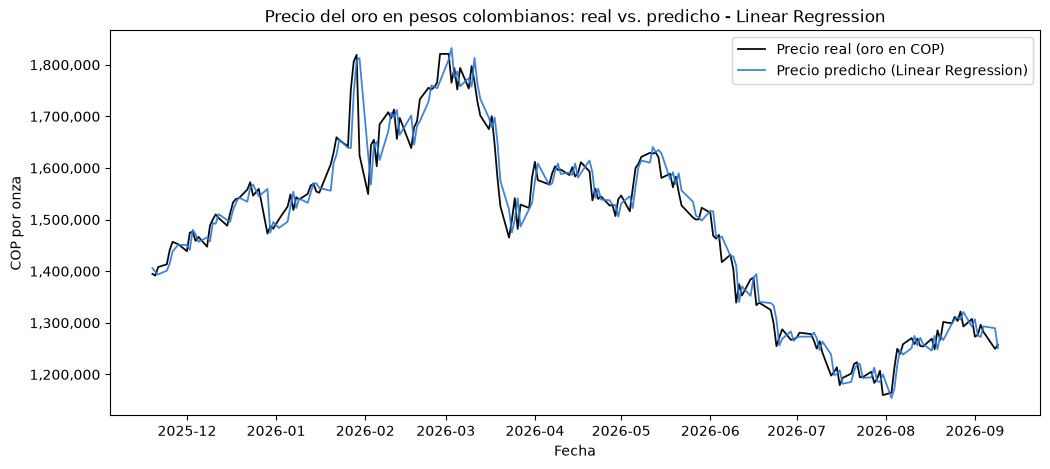

In [14]:
# Necesitamos el precio real de oro_cop en la ventana de test, alineado
precio_real_test = df_modelo.loc[y_te.index, 'oro_cop']

# Reconstruccion: precio_hoy_real * (1 + retorno_predicho) = precio_predicho_manana
# Para comparar en la misma escala de tiempo, usamos el precio del dia anterior
precio_anterior = df_modelo['oro_cop'].shift(1).loc[y_te.index]
precio_predicho = precio_anterior * (1 + pred_final)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te.index, precio_real_test, label='Precio real (oro en COP)', color=COLOR_REAL, linewidth=1.3)
ax.plot(y_te.index, precio_predicho, label=f'Precio predicho ({mejor_nombre})', color=COLOR_PRINCIPAL, alpha=0.9, linewidth=1.3)
ax.set_title(f'Precio del oro en pesos colombianos: real vs. predicho - {mejor_nombre}')
ax.set_ylabel('COP por onza')
ax.set_xlabel('Fecha')
ax.yaxis.set_major_formatter(fmt_cop)
ax.legend()
plt.show()


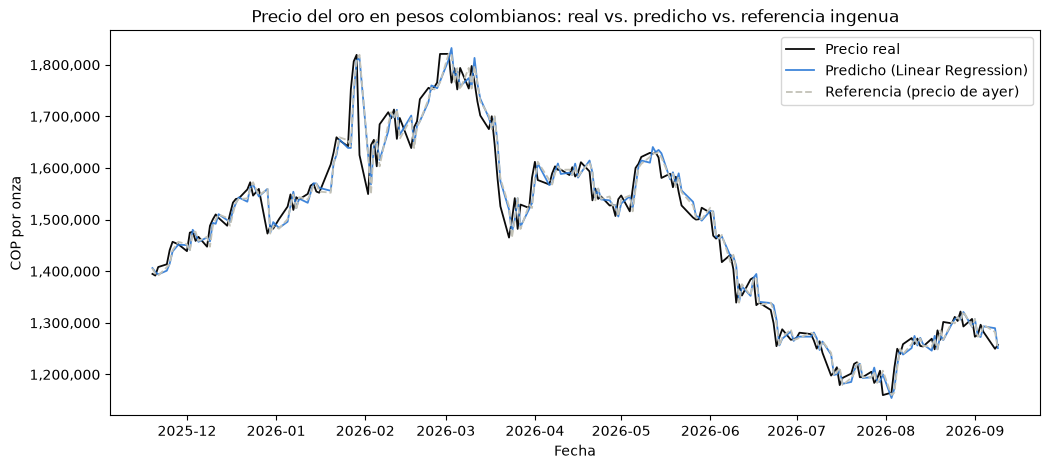

In [15]:
precio_predicho_referencia = precio_anterior  # persistencia = precio de ayer

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te.index, precio_real_test, label='Precio real', color=COLOR_REAL, linewidth=1.3)
ax.plot(y_te.index, precio_predicho, label=f'Predicho ({mejor_nombre})', color=COLOR_PRINCIPAL, alpha=0.9, linewidth=1.3)
ax.plot(y_te.index, precio_predicho_referencia, label='Referencia (precio de ayer)', color=COLOR_MUTED, linestyle='--', linewidth=1.3)
ax.set_title('Precio del oro en pesos colombianos: real vs. predicho vs. referencia ingenua')
ax.set_ylabel('COP por onza')
ax.set_xlabel('Fecha')
ax.yaxis.set_major_formatter(fmt_cop)
ax.legend()
plt.show()


In [16]:
tabla_prediccion = pd.DataFrame({
    'precio_ayer': precio_anterior,
    'retorno_predicho': pred_final,
    'precio_estimado': precio_predicho,
    'precio_real_hoy': precio_real_test,
})

tabla_prediccion['error_COP'] = tabla_prediccion['precio_real_hoy'] - tabla_prediccion['precio_estimado']
tabla_prediccion['error_%'] = (tabla_prediccion['error_COP'] / tabla_prediccion['precio_real_hoy']) * 100

print(tabla_prediccion.head(15).round(2))

            precio_ayer  retorno_predicho  precio_estimado  precio_real_hoy  \
DATE                                                                          
2025-11-19   1405497.10              0.00       1406037.64       1394776.19   
2025-11-20   1394776.19              0.00       1398437.80       1391536.94   
2025-11-21   1391536.94              0.00       1393826.92       1408067.30   
2025-11-24   1408067.30             -0.00       1401041.19       1413426.13   
2025-11-25   1413426.13              0.00       1414788.60       1440978.25   
2025-11-26   1440978.25             -0.00       1438282.38       1456966.99   
2025-11-28   1456966.99             -0.00       1451328.36       1452176.15   
2025-12-01   1452176.15             -0.00       1450595.49       1438901.14   
2025-12-02   1438901.14              0.00       1441444.76       1474764.74   
2025-12-03   1474764.74              0.00       1480254.65       1476430.82   
2025-12-04   1476430.82             -0.00       1471

In [17]:
print("Resumen del error de predicción (en COP por onza):")
print(tabla_prediccion['error_COP'].abs().describe())

print(f"\nError absoluto promedio: {tabla_prediccion['error_COP'].abs().mean():,.0f} COP por onza")
print(f"Error porcentual promedio: {tabla_prediccion['error_%'].abs().mean():.3f}%")

Resumen del error de predicción (en COP por onza):
count       201.000000
mean      23941.000439
std       22219.084752
min         686.042365
25%        9951.156234
50%       17947.928406
75%       33919.362106
max      187935.595808
Name: error_COP, dtype: float64

Error absoluto promedio: 23,941 COP por onza
Error porcentual promedio: 1.601%


In [18]:
tabla_prediccion['precio_estimado_referencia'] = tabla_prediccion['precio_ayer']  # persistencia
tabla_prediccion['error_referencia_COP'] = tabla_prediccion['precio_real_hoy'] - tabla_prediccion['precio_estimado_referencia']

print("Comparación de error absoluto promedio:")
print(f"Tu modelo:    {tabla_prediccion['error_COP'].abs().mean():,.0f} COP ({tabla_prediccion['error_%'].abs().mean():.3f}%)")
print(f"Referencia:   {tabla_prediccion['error_referencia_COP'].abs().mean():,.0f} COP ({(tabla_prediccion['error_referencia_COP'].abs()/tabla_prediccion['precio_real_hoy']*100).mean():.3f}%)")

Comparación de error absoluto promedio:
Tu modelo:    23,941 COP (1.601%)
Referencia:   24,175 COP (1.614%)


In [19]:
print(df_ranking.to_string())

                 modelo  rmse_promedio  mejora_%  ventanas_ganadas
0     Linear Regression       0.014715  3.871328                 5
1       Huber Regressor       0.014823  3.166136                 5
2        Bayesian Ridge       0.014950  2.336263                 6
3           Extra Trees       0.014994  2.048421                 5
4                 Ridge       0.015003  1.991056                 5
5         Random Forest       0.015063  1.599238                 5
6              AdaBoost       0.015122  1.213228                 5
7            ElasticNet       0.015279  0.183638                 6
8                 Lasso       0.015294  0.087033                 5
9   K-Nearest Neighbors       0.015297  0.067199                 5
10             LightGBM       0.015388 -0.523727                 4
11    Gradient Boosting       0.015406 -0.645043                 5
12            SVR (RBF)       0.015687 -2.477632                 2
13              XGBoost       0.015877 -3.721575              

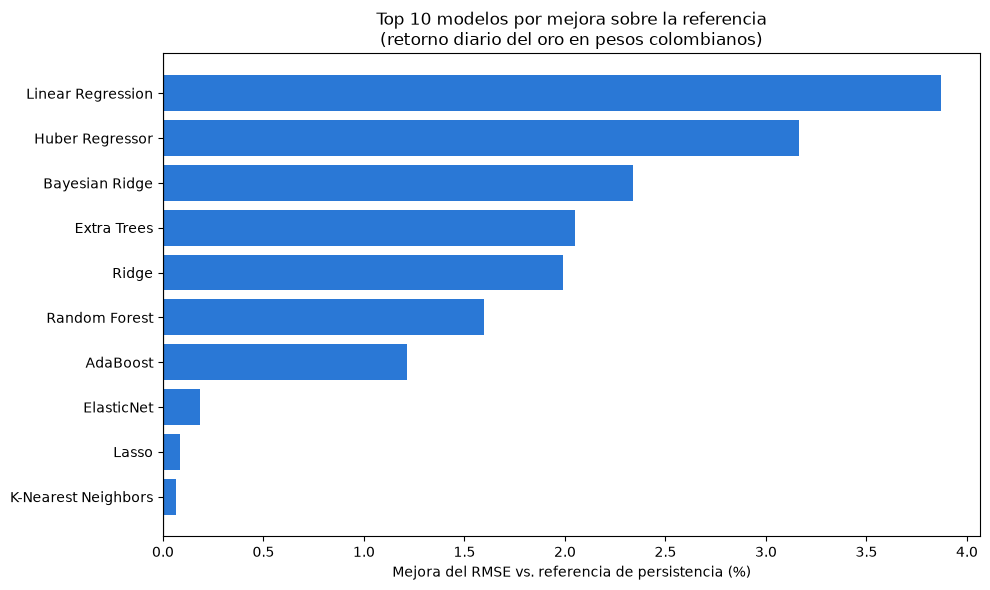

In [20]:
top10 = df_ranking.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colores = [COLOR_PRINCIPAL if v > 0 else COLOR_CRITICO for v in top10['mejora_%']]
ax.barh(top10['modelo'][::-1], top10['mejora_%'][::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mejora del RMSE vs. referencia de persistencia (%)')
ax.set_title('Top 10 modelos por mejora sobre la referencia\n(retorno diario del oro en pesos colombianos)')
plt.tight_layout()
plt.show()


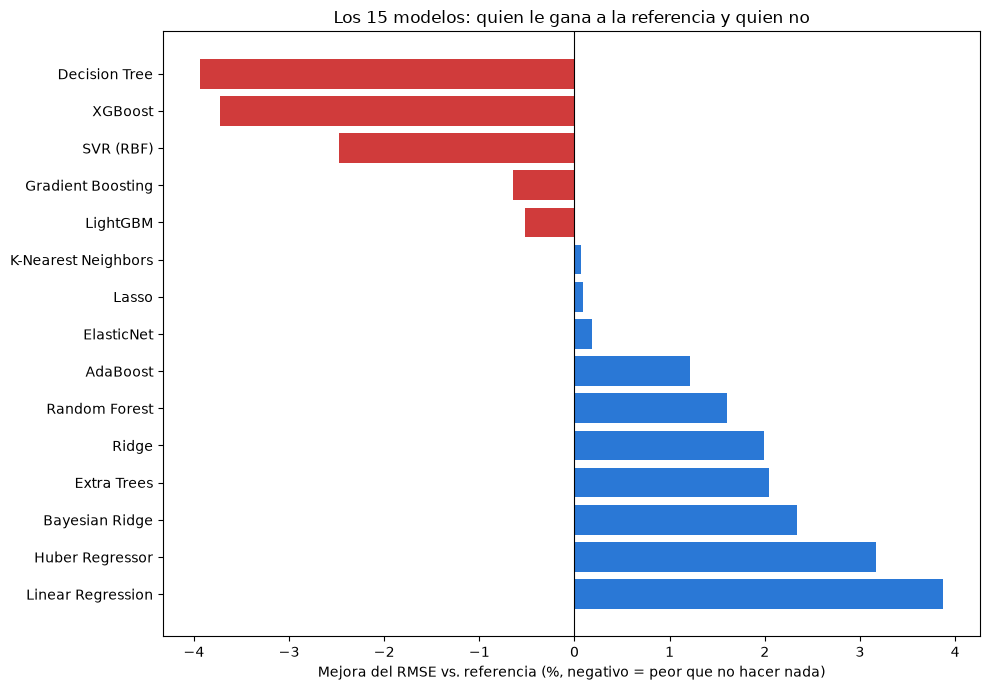

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
df_plot = df_ranking.sort_values("rmse_promedio")
colores2 = [COLOR_PRINCIPAL if m > 0 else COLOR_CRITICO for m in df_plot['mejora_%']]
ax.barh(df_plot['modelo'], df_plot['mejora_%'], color=colores2)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mejora del RMSE vs. referencia (%, negativo = peor que no hacer nada)')
ax.set_title('Los 15 modelos: quien le gana a la referencia y quien no')
plt.tight_layout()
plt.show()


## Predicción para el día siguiente

Hasta aquí evaluamos y comparamos modelos sobre ventanas históricas (backtesting). En esta sección damos el paso final: reentrenamos el modelo campeón con **todo** el histórico disponible hasta hoy y lo usamos para predecir el retorno y el precio del oro en pesos colombianos del **próximo día hábil**. Esta es la predicción real que consume la página web del proyecto — se genera aquí, en este cuaderno, cada vez que se ejecuta.


In [22]:
# Construimos una fila adicional para el proximo dia habil. Sus variables
# (rezagos de USD/COP, variables macro rezagadas 1 dia, dia de la semana)
# solo dependen de datos ya conocidos -- nunca del futuro -- por lo que se
# pueden calcular de antemano.
proximo_dia = df.index[-1] + pd.tseries.offsets.BDay(1)

columnas_base = ['oro_xauusd_Close', 'usd_cop_Close', 'oro_cop', 'dxy_Close',
                  'vix_Close', 'wti_crudo_Close', 'bono_10y_Close']
fila_vacia = pd.DataFrame(np.nan, index=[proximo_dia], columns=columnas_base)
df_ext = pd.concat([df[columnas_base], fila_vacia])
df_ext.index.name = 'DATE'

df_ext['retorno_oro_cop']  = df_ext['oro_cop'].pct_change(fill_method=None)
df_ext['retorno_usd_cop']  = df_ext['usd_cop_Close'].pct_change(fill_method=None)
df_ext['retorno_dxy']      = df_ext['dxy_Close'].pct_change(fill_method=None)
df_ext['retorno_vix']      = df_ext['vix_Close'].pct_change(fill_method=None)
df_ext['retorno_wti']      = df_ext['wti_crudo_Close'].pct_change(fill_method=None)
df_ext['retorno_bono_10y'] = df_ext['bono_10y_Close'].pct_change(fill_method=None)

for lag in [5, 8, 10, 16]:
    df_ext[f'usd_cop_lag_{lag}'] = df_ext['retorno_usd_cop'].shift(lag)

df_ext['retorno_dxy_lag1']      = df_ext['retorno_dxy'].shift(1)
df_ext['retorno_vix_lag1']      = df_ext['retorno_vix'].shift(1)
df_ext['retorno_wti_lag1']      = df_ext['retorno_wti'].shift(1)
df_ext['retorno_bono_10y_lag1'] = df_ext['retorno_bono_10y'].shift(1)

dummies_ext = pd.get_dummies(df_ext.index.dayofweek, prefix='dia', drop_first=True)
dummies_ext.index = df_ext.index
for col in ['dia_1', 'dia_2', 'dia_3', 'dia_4']:
    if col not in dummies_ext.columns:
        dummies_ext[col] = False
df_ext = pd.concat([df_ext, dummies_ext[['dia_1', 'dia_2', 'dia_3', 'dia_4']]], axis=1)

print(f"Prediciendo para: {proximo_dia.date()}")
df_ext[FEATURES].tail(3)


Prediciendo para: 2026-09-10


,usd_cop_lag_5,usd_cop_lag_8,usd_cop_lag_10,usd_cop_lag_16,dia_1,dia_2,dia_3,dia_4,retorno_dxy_lag1,retorno_vix_lag1,retorno_wti_lag1,retorno_bono_10y_lag1
DATE,,,,,,,,,,,,
2026-09-08,0.012463,0.009952,-0.009878,-0.007094,True,False,False,False,0.001616,0.014665,0.001972,0.004620
2026-09-09,0.002243,0.010882,0.006396,0.001988,False,True,False,False,-0.003227,0.081900,0.016944,0.004599
2026-09-10,-0.012214,0.010928,0.009952,0.000936,False,False,True,False,-0.000577,0.047074,0.044609,0.006450


In [23]:
from sklearn.base import clone

# Reentrenamos el modelo campeon (identificado arriba por mejora_%) con
# TODO el historico disponible, no solo con una ventana de validacion.
modelo_final = clone(modelos[mejor_nombre])
df_entrena_final = df_ext.dropna(subset=FEATURES + [TARGET])
modelo_final.fit(df_entrena_final[FEATURES], df_entrena_final[TARGET])

fila_manana = df_ext.iloc[[-1]]
if fila_manana[FEATURES].isna().any(axis=None):
    faltantes = fila_manana[FEATURES].columns[fila_manana[FEATURES].isna().any()].tolist()
    raise ValueError(f"Features incompletas para el dia a predecir: {faltantes}")

retorno_predicho_manana = float(modelo_final.predict(fila_manana[FEATURES])[0])

precio_hoy = float(df_ext['oro_cop'].dropna().iloc[-1])
precio_predicho_manana = precio_hoy * (1 + retorno_predicho_manana)

print(f"Modelo campeón: {mejor_nombre}")
print(f"Precio hoy ({df_ext.index[-2].date()}): {precio_hoy:,.0f} COP por onza")
print(f"Retorno predicho para {proximo_dia.date()}: {retorno_predicho_manana*100:.3f}%")
print(f"Precio predicho para {proximo_dia.date()}: {precio_predicho_manana:,.0f} COP por onza")


Modelo campeón: Linear Regression
Precio hoy (2026-09-09): 1,257,214 COP por onza
Retorno predicho para 2026-09-10: -0.143%
Precio predicho para 2026-09-10: 1,255,417 COP por onza


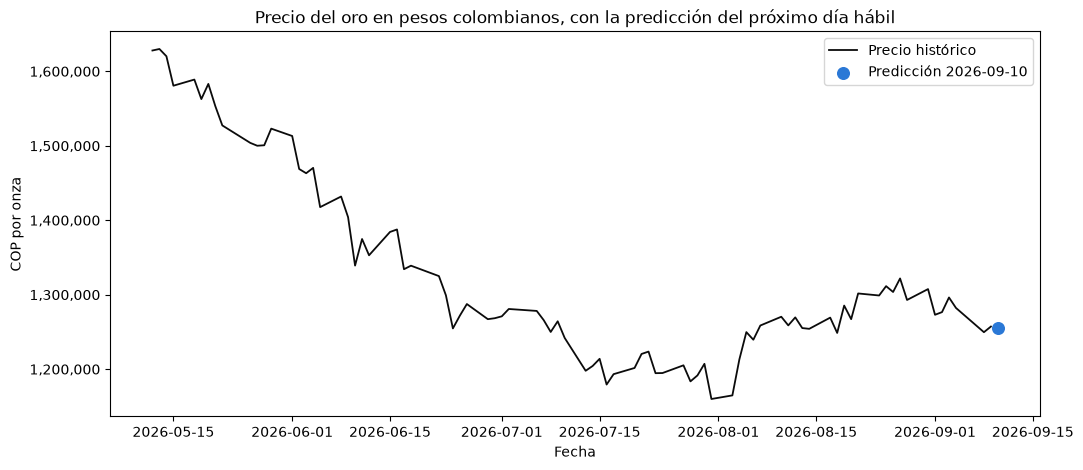

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
cutoff = df_ext.index[-2] - pd.Timedelta(days=120)
tramo = df_ext['oro_cop'].iloc[:-1]
tramo = tramo[tramo.index >= cutoff]
ax.plot(tramo.index, tramo.values, color=COLOR_REAL, linewidth=1.3, label='Precio histórico')
ax.scatter([proximo_dia], [precio_predicho_manana], color=COLOR_PRINCIPAL, s=70, zorder=5,
           label=f'Predicción {proximo_dia.date()}')
ax.set_title('Precio del oro en pesos colombianos, con la predicción del próximo día hábil')
ax.set_ylabel('COP por onza')
ax.set_xlabel('Fecha')
ax.yaxis.set_major_formatter(fmt_cop)
ax.legend()
plt.show()


### Guardado de resultados para la página web

Estos archivos son los que consume la página del producto (`docs/index.html`, generada por `src/06_build_pagina.py`). Se guardan en `dashboard_data/` dentro del propio repositorio cuando este cuaderno corre fuera de Colab (por ejemplo, en la ejecución automática diaria de GitHub Actions).


In [25]:
OUT_DIR = "dashboard_data/"  # siempre relativo a la raiz del repo (no depende de Colab/Drive)
os.makedirs(OUT_DIR, exist_ok=True)

historico_out = df_ext.iloc[:-1][columnas_base + ['retorno_oro_cop']].reset_index()
historico_out['DATE'] = historico_out['DATE'].dt.strftime('%Y-%m-%d')
historico_out.to_csv(OUT_DIR + 'historico.csv', index=False)
print(f"historico.csv: {len(historico_out)} filas")


historico.csv: 1426 filas


In [26]:
# Actualizamos el log de predicciones, incluyendo el seguimiento de
# aciertos para los dias cuyo precio real ya se conoce.
pred_path = OUT_DIR + 'prediccion.csv'
columnas_log = ['fecha_prediccion', 'fecha_objetivo', 'precio_hoy', 'retorno_predicho',
                'precio_predicho', 'precio_real', 'error_COP', 'error_pct', 'acierto_direccion']

if os.path.exists(pred_path):
    log = pd.read_csv(pred_path)
else:
    log = pd.DataFrame(columns=columnas_log)

nueva_fila = {
    'fecha_prediccion': df_ext.index[-2].strftime('%Y-%m-%d'),
    'fecha_objetivo': proximo_dia.strftime('%Y-%m-%d'),
    'precio_hoy': precio_hoy,
    'retorno_predicho': retorno_predicho_manana,
    'precio_predicho': precio_predicho_manana,
    'precio_real': None, 'error_COP': None, 'error_pct': None, 'acierto_direccion': None,
}
log = log[log['fecha_objetivo'] != nueva_fila['fecha_objetivo']]
fila_df = pd.DataFrame([nueva_fila])
log = fila_df if log.empty else pd.concat([log, fila_df], ignore_index=True)

precios_reales = historico_out.set_index('DATE')['oro_cop']
for i, row in log.iterrows():
    objetivo = row['fecha_objetivo']
    if objetivo in precios_reales.index and pd.notna(precios_reales[objetivo]):
        real = float(precios_reales[objetivo])
        predicho = float(row['precio_predicho'])
        hoy_ = float(row['precio_hoy'])
        log.at[i, 'precio_real'] = real
        log.at[i, 'error_COP'] = real - predicho
        log.at[i, 'error_pct'] = (real - predicho) / real * 100
        log.at[i, 'acierto_direccion'] = (predicho - hoy_) * (real - hoy_) > 0

log = log.sort_values('fecha_objetivo').reset_index(drop=True)
log.to_csv(pred_path, index=False)
log.tail(10)


,fecha_prediccion,fecha_objetivo,precio_hoy,retorno_predicho,precio_predicho,precio_real,error_COP,error_pct,acierto_direccion
13,2026-08-25,2026-08-26,1.319603e+06,-0.001999,1.316964e+06,1303644.128776,-13320.160235,-1.021764,True
14,2026-08-26,2026-08-27,1.303644e+06,0.000886,1.304799e+06,1321833.700487,17034.79539,1.288725,True
15,2026-08-27,2026-08-28,1.321834e+06,0.000496,1.322490e+06,1292926.597891,-29563.252474,-2.286538,False
16,2026-08-28,2026-08-31,1.292927e+06,-0.001266,1.291290e+06,1307536.232046,16246.064907,1.242494,False
17,2026-09-01,2026-09-02,1.273024e+06,0.003293,1.277216e+06,1276587.015731,-628.884197,-0.049263,True
18,2026-09-02,2026-09-03,1.276587e+06,-0.002027,1.274000e+06,1296274.672827,22274.879648,1.718377,False
19,2026-09-03,2026-09-04,1.296275e+06,-0.002124,1.293522e+06,1282212.196163,-11309.832427,-0.882056,True
20,2026-09-04,2026-09-07,1.282212e+06,0.000387,1.282708e+06,NaN,NaN,NaN,NaN
21,2026-09-08,2026-09-09,1.249641e+06,0.000324,1.250045e+06,1257213.706951,7168.285876,0.570172,True
22,2026-09-09,2026-09-10,1.257214e+06,-0.001429,1.255417e+06,None,None,None,None


In [27]:
validas = log.dropna(subset=['error_pct'])
resumen = {
    'fecha_actualizacion': pd.Timestamp.now(tz='UTC').strftime('%Y-%m-%d %H:%M UTC'),
    'precio_oro_cop_hoy': precio_hoy,
    'precio_oro_cop_predicho_manana': precio_predicho_manana,
    'retorno_predicho_manana_pct': retorno_predicho_manana * 100,
    'fecha_objetivo': proximo_dia.strftime('%Y-%m-%d'),
    'error_abs_promedio_pct': float(validas['error_pct'].abs().mean()) if len(validas) else None,
    'aciertos_direccion_pct': float(validas['acierto_direccion'].mean() * 100) if len(validas) else None,
    'predicciones_evaluadas': int(len(validas)),
    'modelo_campeon': mejor_nombre,
    'mejora_rmse_vs_referencia_pct': float(df_ranking.iloc[0]['mejora_%']),
}
pd.DataFrame([resumen]).to_csv(OUT_DIR + 'resumen.csv', index=False)
resumen


{'fecha_actualizacion': '2026-09-09 23:52 UTC',
 'precio_oro_cop_hoy': 1257213.7069514766,
 'precio_oro_cop_predicho_manana': 1255417.3723374533,
 'retorno_predicho_manana_pct': -0.14288220086138187,
 'fecha_objetivo': '2026-09-10',
 'error_abs_promedio_pct': 1.3864706582291344,
 'aciertos_direccion_pct': 52.38095238095239,
 'predicciones_evaluadas': 21,
 'modelo_campeon': 'Linear Regression',
 'mejora_rmse_vs_referencia_pct': 3.8713277017649093}

In [28]:
# Ranking de los 15 modelos, calculado arriba en este mismo cuaderno
# (no es una tabla estatica: se recalcula cada vez que este cuaderno corre).
df_ranking.rename(columns={'mejora_%': 'mejora_pct'}).to_csv(OUT_DIR + 'metricas_modelos.csv', index=False)
print(f"metricas_modelos.csv: {len(df_ranking)} modelos")


metricas_modelos.csv: 15 modelos
